<a href="https://colab.research.google.com/github/Ashleylq/house-price-regressor/blob/main/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Load The Data**

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/wblakecannon/ames/refs/heads/master/data/housing.csv")

# **Delete ID Rows**

In [ ]:
df = df.drop(['Unnamed: 0', 'Order', 'PID'], axis=1)
df.columns

Index(['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street',
       'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Gara

#**Seperate Target**

In [ ]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# **Seperate Categorical and Numerical Features**

MS Subclass is a coded categorical feature, so dtype will not be able to differentiate it from numerical features. So lets convert it to category.

In [ ]:
X["MS SubClass"] = X["MS SubClass"].astype('category')
X["MS SubClass"].dtype

CategoricalDtype(categories=[20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 150, 160,
                  180, 190],
, ordered=False, categories_dtype=int64)

In [ ]:
cat = X.select_dtypes(exclude=["number"]).columns.tolist()
num = X.select_dtypes(include=["number"]).columns.tolist()
num

['Lot Frontage',
 'Lot Area',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Mas Vnr Area',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'TotRms AbvGrd',
 'Fireplaces',
 'Garage Yr Blt',
 'Garage Cars',
 'Garage Area',
 'Wood Deck SF',
 'Open Porch SF',
 'Enclosed Porch',
 '3Ssn Porch',
 'Screen Porch',
 'Pool Area',
 'Misc Val',
 'Mo Sold',
 'Yr Sold',
 'Tot Liv Area']

In [ ]:
cat = X[cat]
num = X[num]

# **Target Analysis**

In [ ]:
y.describe(), y.skew(), y.kurt()

(count      2930.000000
 mean     180796.060068
 std       79886.692357
 min       12789.000000
 25%      129500.000000
 50%      160000.000000
 75%      213500.000000
 max      755000.000000
 Name: SalePrice, dtype: float64,
 np.float64(1.7435000757376466),
 np.float64(5.118899951130896))

Sale Price is right skewed so lets apply log1p and compare it on a histogram.

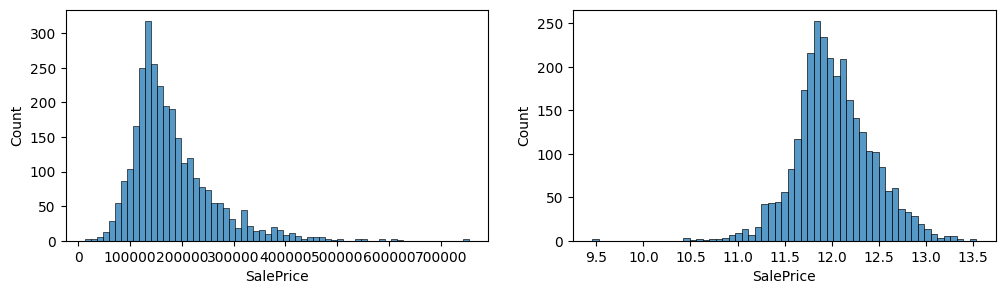

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

sns.histplot(data=y, ax=ax1)

transformed_y = np.log1p(y)
sns.histplot(data=transformed_y, ax=ax2)

plt.show()

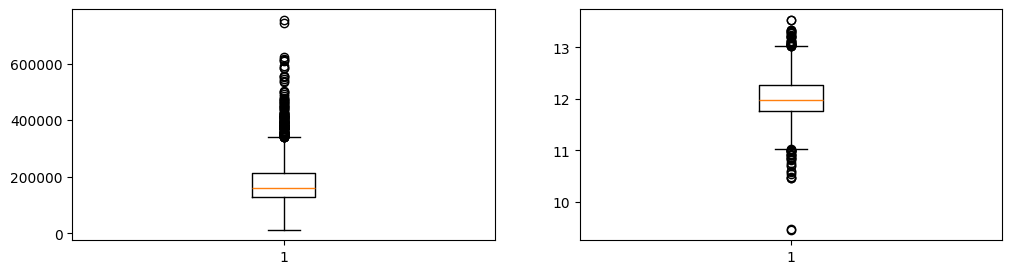

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.boxplot(y)
ax2.boxplot(transformed_y)
plt.show()

# **Missing Values**

In [ ]:
na_count = X.isna().sum()
na_count[na_count>0]

,0
Lot Frontage,490
Alley,2732
Mas Vnr Type,1775
Mas Vnr Area,23
Bsmt Qual,80
Bsmt Cond,80
Bsmt Exposure,83
BsmtFin Type 1,80
BsmtFin SF 1,1
BsmtFin Type 2,81


Most of the na columns indicate an absence of the feature. So we can impute the mode for numerical columns and just make a new missing category for categorical ones.

# **Numeric Column Skewness**

In [ ]:
skew_values = num.skew(numeric_only=True)
skewed_columns = skew_values[skew_values.abs() > 1].index.tolist()
skew_values[skew_values.abs() > 1]

,0
Lot Frontage,1.499067
Lot Area,12.820898
Mas Vnr Area,2.606985
BsmtFin SF 1,1.416182
BsmtFin SF 2,4.139978
Total Bsmt SF,1.156204
1st Flr SF,1.469429
Low Qual Fin SF,12.118162
Gr Liv Area,1.274110
Bsmt Half Bath,3.940795


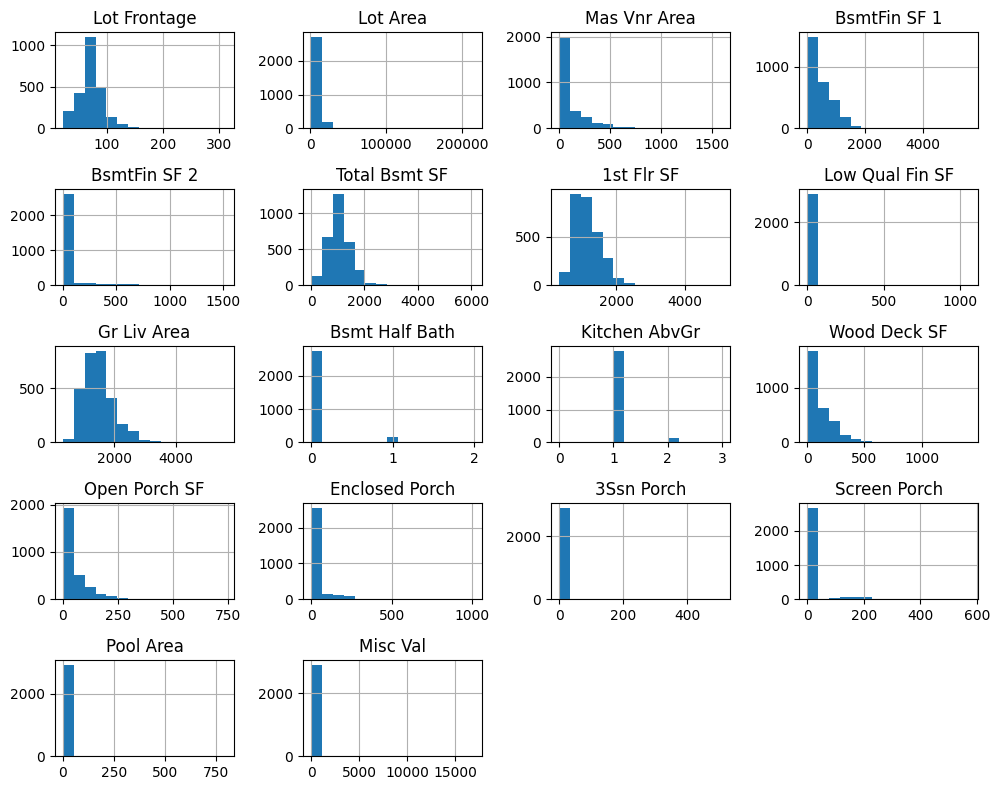

In [ ]:
X[skewed_columns].hist(bins=15, figsize=(10, 8))
plt.tight_layout()
plt.show()

Since all of the columns have positive skew let's see if a log1p transform can improve it.

In [ ]:
X[skewed_columns] = X[skewed_columns].apply(np.log1p)
X[skewed_columns].skew()

,0
Lot Frontage,-0.849028
Lot Area,-0.498335
Mas Vnr Area,0.528999
BsmtFin SF 1,-0.622259
BsmtFin SF 2,2.449714
Total Bsmt SF,-4.967089
1st Flr SF,0.062356
Low Qual Fin SF,8.578846
Gr Liv Area,0.016484
Bsmt Half Bath,3.783687


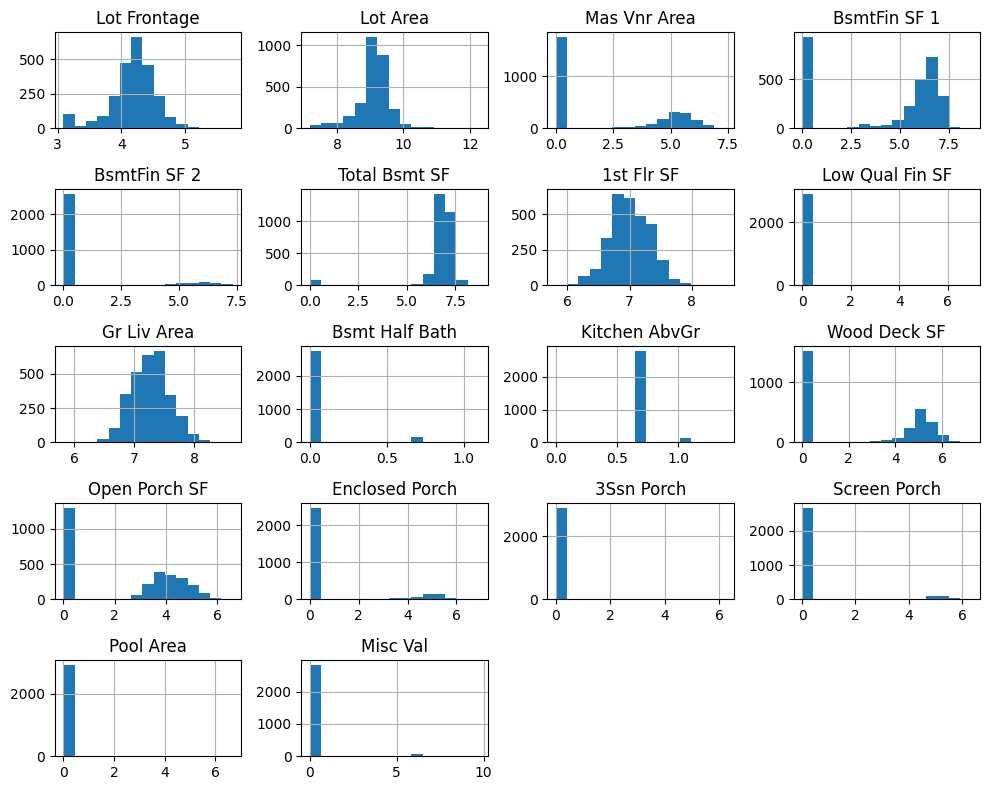

In [ ]:
X[skewed_columns].hist(bins=15, figsize=(10, 8))
plt.tight_layout()
plt.show()

# **Numerical Outliers**

In [ ]:
Q1 = num.quantile(0.25)
Q3 = num.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier_mask = num[(num <= lower) | (num >= upper)]
outlier_count = outlier_mask.sum().sort_values(ascending=False)
outlier_count[outlier_count > 0]

,0
Lot Area,3975840.0
Gr Liv Area,230098.0
Misc Val,148361.0
BsmtFin SF 2,145637.0
Mas Vnr Area,122176.0
Total Bsmt SF,111704.0
1st Flr SF,111158.0
Bsmt Unf SF,102468.0
Enclosed Porch,67424.0
Garage Area,46937.0


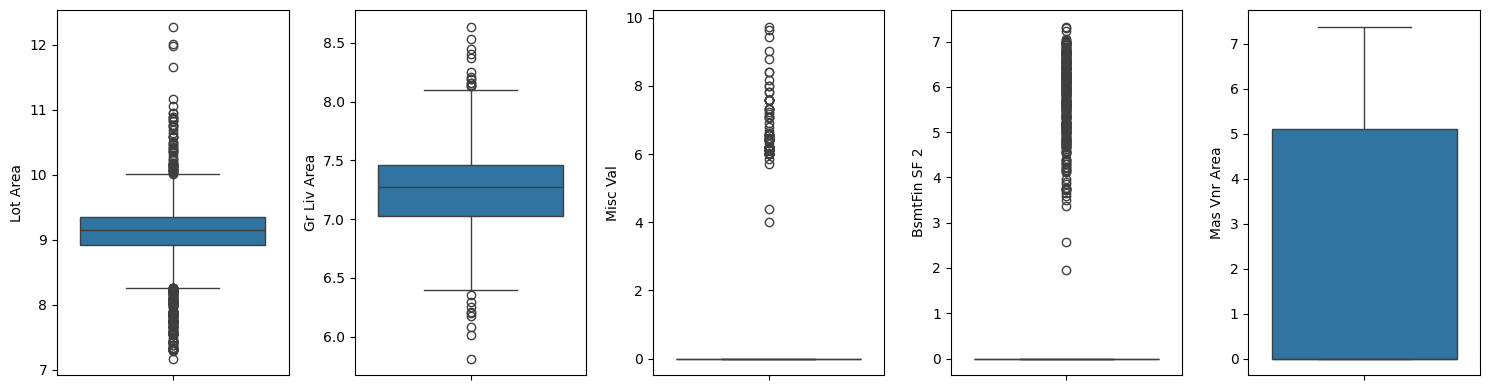

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, col in enumerate(outlier_count.head(5).index.tolist()):
  sns.boxplot(data=X, y=col, ax=axes[i])
plt.tight_layout()
plt.show()

# **Target Feature Correlation**

In [ ]:
target_corr = num.corrwith(transformed_y).abs().sort_values(ascending=False)
target_corr

,0
Overall Qual,0.825645
Gr Liv Area,0.695863
Garage Cars,0.675318
Garage Area,0.651132
Total Bsmt SF,0.625099
Year Built,0.615485
1st Flr SF,0.602629
Year Remod/Add,0.586153
Garage Yr Blt,0.580502
Full Bath,0.577335


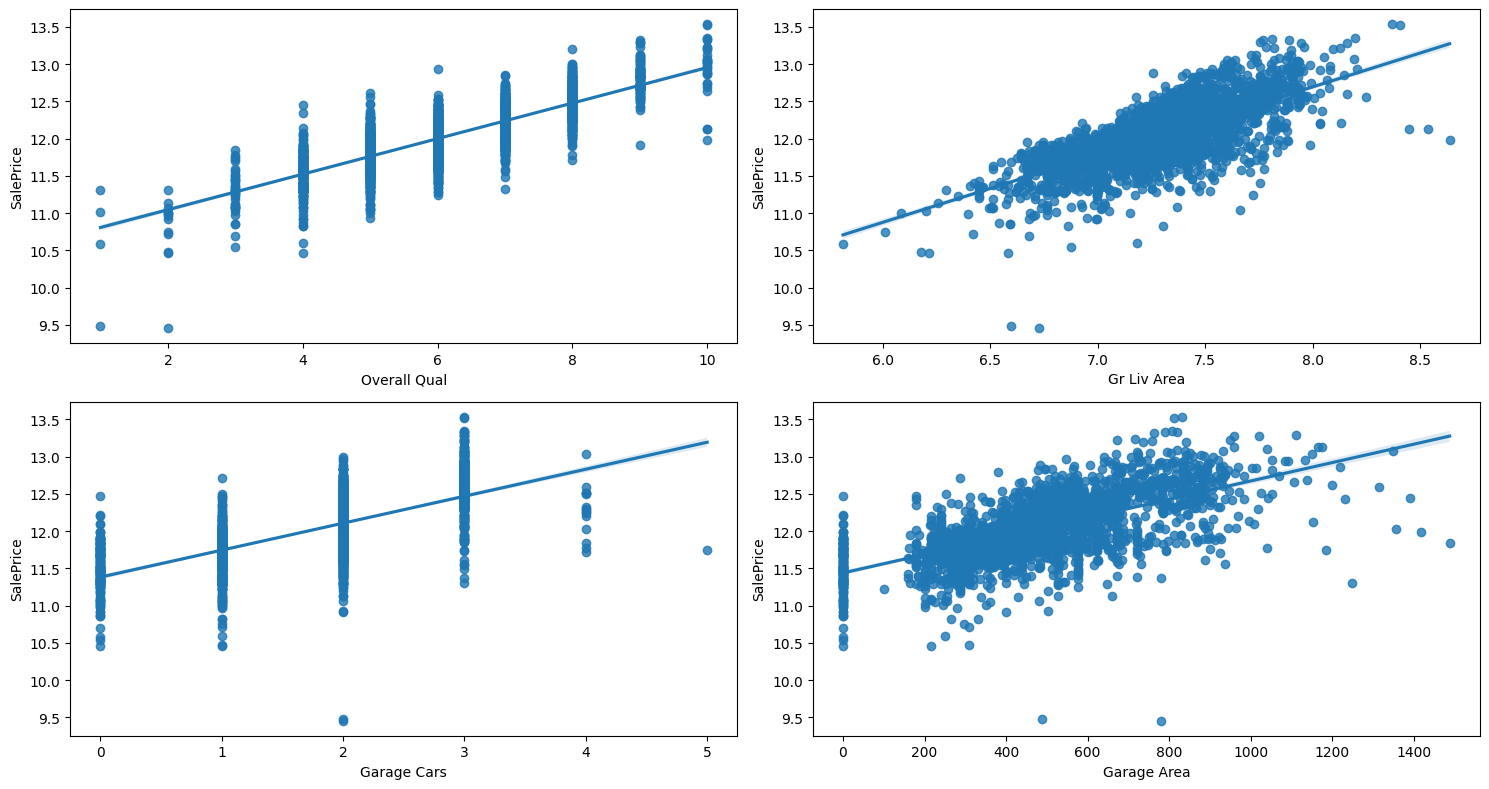

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(target_corr.head(4).index.tolist()):
  sns.regplot(x=X[col], y=transformed_y, ax=axes[i])
plt.tight_layout()
plt.show()

# **Feature Correlation**

In [ ]:
corr_matrix = num.corr()
corr_matrix.head(5)

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
Lot Frontage,1.000000,0.491313,0.212042,-0.074448,0.121562,0.091712,0.222407,0.215583,0.045999,0.116743,...,0.358505,0.120084,0.163040,0.012758,0.028564,0.076666,0.173947,0.044476,0.011085,-0.007547
Lot Area,0.491313,1.000000,0.097188,-0.034759,0.023258,0.021682,0.126830,0.191555,0.083150,0.023658,...,0.212822,0.157212,0.103760,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085
Overall Qual,0.212042,0.097188,1.000000,-0.094812,0.597027,0.569609,0.429418,0.284118,-0.041287,0.270058,...,0.563503,0.255663,0.298412,-0.140332,0.018240,0.041615,0.030399,0.005179,0.031103,-0.020719
Overall Cond,-0.074448,-0.034759,-0.094812,1.000000,-0.368773,0.047680,-0.135340,-0.050935,0.041134,-0.136819,...,-0.153754,0.020344,-0.068934,0.071459,0.043852,0.044055,-0.016787,0.034056,-0.007295,0.031207
Year Built,0.121562,0.023258,0.597027,-0.368773,1.000000,0.612095,0.313292,0.279870,-0.027415,0.128998,...,0.480131,0.228964,0.198365,-0.374364,0.015803,-0.041436,0.002213,-0.011011,0.014577,-0.013197


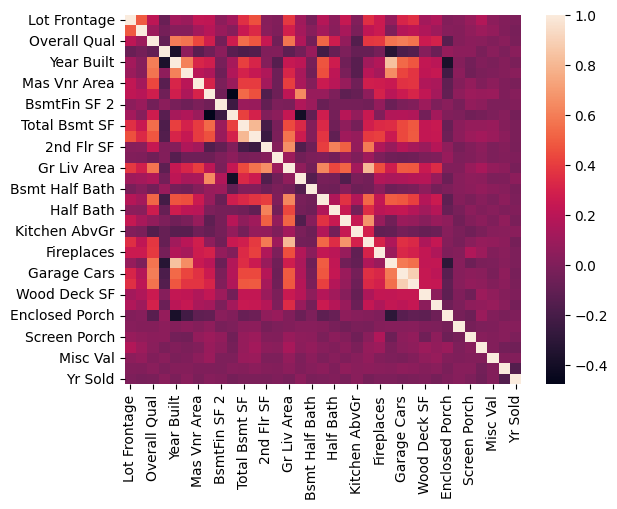

In [ ]:
sns.heatmap(corr_matrix)
plt.show()

# **Category Analysis**

In [ ]:
cat.describe(include=["category", "object"])

,MS SubClass,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,2930,198,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,16,7,2,2,4,4,3,5,3,28,...,6,3,5,5,3,4,4,5,10,6
top,20,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,1079,2273,2918,120,1859,2633,2927,2140,2789,443,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


In [ ]:
from sklearn.feature_selection import mutual_info_regression
encoded = cat.apply(lambda x: x.astype('category').cat.codes)
mi_scores = mutual_info_regression(encoded, transformed_y, discrete_features=True)
mi_df = pd.DataFrame({'Feature': cat.columns.tolist(), 'MI Score': mi_scores})
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
mi_df

['Neighborhood', 'Bsmt Qual', 'Kitchen Qual', 'Exter Qual', 'MS SubClass']

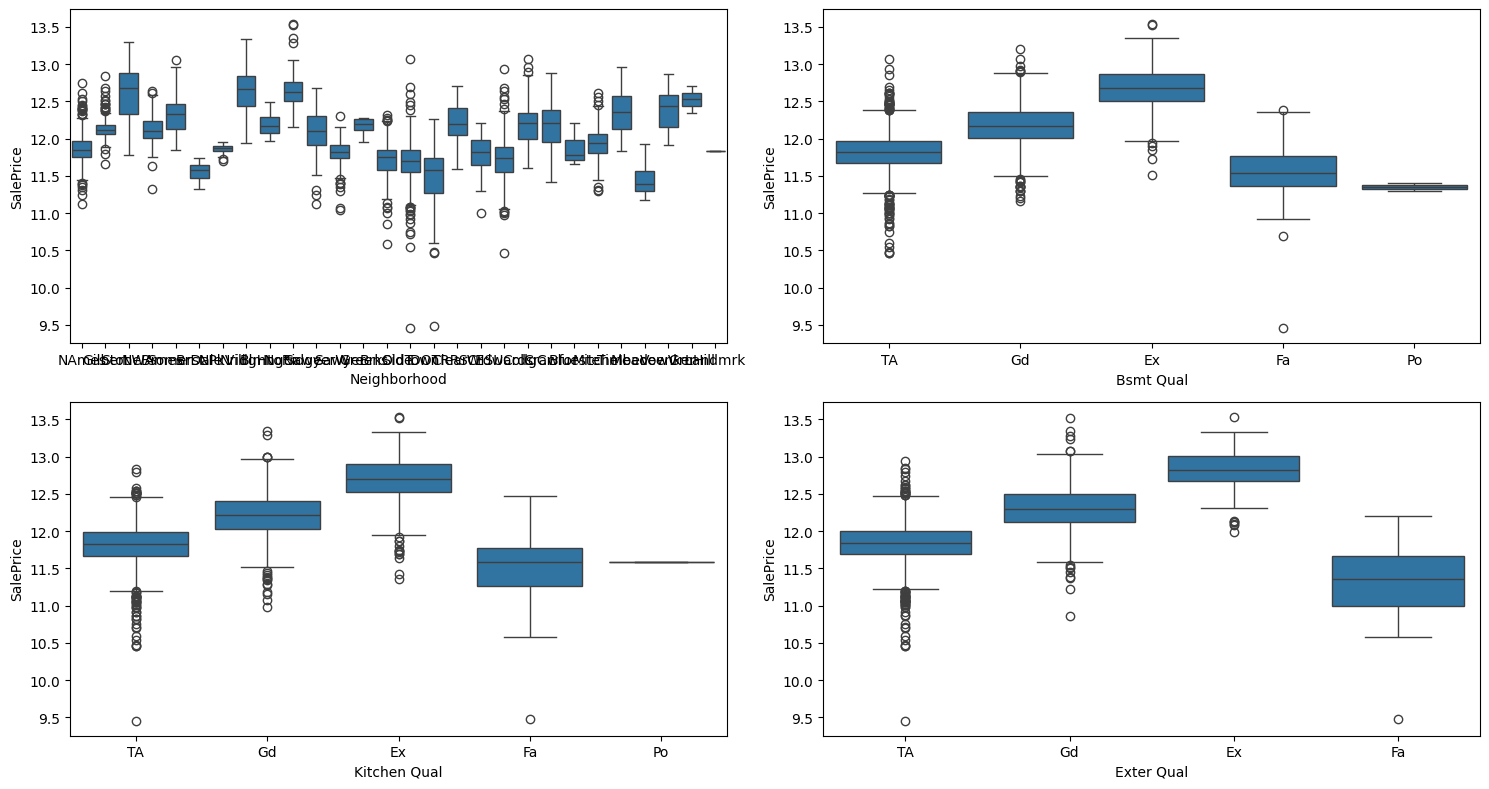

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15,8))
axes = axes.flatten()
for i, col in enumerate(mi_df["Feature"].head(4).tolist()):
  sns.boxplot(x=X[col], y=transformed_y, ax=axes[i])
plt.tight_layout()
plt.show()

# **Feature Engineering**

In [ ]:
X['Tot Liv Area'] = X['Total Bsmt SF'].fillna(0) + X['Gr Liv Area']
X['Tot Rooms'] = X['TotRms AbvGrd'] + X['Bsmt Full Bath'].fillna(0) + X['Bsmt Half Bath'].fillna(0)
X['HouseAge'] = X['Yr Sold'] - X['Year Built']
X['Years Since Remod'] = X['Yr Sold'] - X['Year Remod/Add']
X[['Tot Liv Area', 'Tot Rooms', 'HouseAge', 'Years Since Remod']]

,Tot Liv Area,Tot Rooms,HouseAge,Years Since Remod
0,14.398406,8.000000,50,50
1,13.582381,5.000000,49,49
2,14.385868,6.000000,52,52
3,15.309834,9.000000,42,42
4,14.230444,6.000000,13,12
...,...,...,...,...
2925,13.823495,7.000000,22,22
2926,13.568452,6.000000,23,23
2927,13.695062,6.693147,14,14
2928,14.474118,7.000000,32,31
